In [1]:
import pandas as pd

In [2]:
# Uplaoding tick data, which includes counties and whether the specific species of ticks are established or not in the county.

In [3]:
tick_df = pd.read_excel('Downloads/county_cases.xlsx', sheet_name='Ixodes records 2025', header=1)

#print(cases_df.head())
print(tick_df.columns.tolist())
print(tick_df.shape)

['FIPSCode', 'State', 'County', 'Ixodes_scapularis_County_Status', 'Ixodes_scapularis_data_source', 'Ixodes_pacificus_county_status', 'Ixodes_pacificus_data_source']
(3111, 7)


In [4]:
# A total of 49 states are present, Alaska (AK) is left out of this list because this specific species of ticks are not present in AK. 
# Hawaii is also left out of this list as well. 
# Good to note that DC is listed as a state in this data, hence why we have 49 states with two states missing
print(tick_df['State'].unique())

['AL' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'ID' 'IL' 'IN' 'IA'
 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE' 'NV' 'NH'
 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD' 'TN' 'TX'
 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']


In [5]:
# Uploading Lyme Disease data, which shows the amount of Lyme Disease cases in each county. 

In [6]:
ld = pd.read_csv('Downloads/ld_county.csv', encoding='windows-1252')

# print(ld_county.head())
print(ld.columns.tolist())
print(ld.shape)

['Ctyname', 'stname', 'ststatus', 'stcode', 'ctycode', 'Cases2001', 'Cases2002', 'Cases2003', 'Cases2004', 'Cases2005', 'Cases2006', 'Cases2007', 'Cases2008', 'Cases2009', 'Cases2010', 'Cases2011', 'Cases2012', 'Cases2013', 'Cases2014', 'Cases2015', 'Cases2016', 'Cases2017', 'Cases2018', 'Cases2019', 'Cases2020', 'cases2021', 'cases2022', 'cases2023']
(3153, 28)


In [7]:
# Creating a FIPS code for the LD data set to create a primary key between both tick and lyme disease datasets
ld['FIPS'] = ld['stcode'].astype(str).str.zfill(2) + ld['ctycode'].astype(str).str.zfill(3)
print(ld[['Ctyname','FIPS']].head())

          Ctyname   FIPS
0  Autauga County  01001
1  Baldwin County  01003
2  Barbour County  01005
3     Bibb County  01007
4   Blount County  01009


In [8]:
tick_df['FIPS'] = tick_df['FIPSCode'].astype(str).str.zfill(5)
print(tick_df[['County','FIPS']].head())

           County   FIPS
0  Autauga County  01001
1  Baldwin County  01003
2  Barbour County  01005
3     Bibb County  01007
4   Blount County  01009


In [9]:
matched = ld['FIPS'].isin(tick_df['FIPS'])
print(matched.sum(), 'out of', len(ld), 'counties matched')

3110 out of 3153 counties matched


In [10]:
# Downloading cleaned datasets to upload into SQL
ld.to_csv('lyme_cases.csv', index=False)
tick_df.to_csv('tick_data.csv', index=False)

In [11]:
# Uploading population data in each county

In [12]:
population_df = pd.read_csv('Downloads/co-est2025-alldata.csv', encoding='windows-1252')
print(population_df.shape)

(3195, 99)


In [13]:
population_df['FIPS'] = population_df['STATE'].astype(str).str.zfill(2) + population_df['COUNTY'].astype(str).str.zfill(3)

pop_df = population_df[population_df['COUNTY'] != 0].copy()

pop_df.to_csv('Downloads/population_cleaned.csv', index=False)

print(pop_df.shape)

(3144, 100)


In [14]:
# Uploading the rural/urban dataset 

In [15]:
urban_rural_df = pd.read_csv('Downloads/data-table.csv', dtype={'Location': str})
print(urban_rural_df.shape)

(3144, 5)


In [16]:
urban_rural_df = urban_rural_df.rename(columns={'Location': 'FIPS', '2023 Code': 'URBAN_RURAL_CODE'})

urban_rural_df.to_csv('Downloads/urban_rural_cleaned.csv', index=False)

print(urban_rural_df.shape)
print(urban_rural_df.columns.tolist())

(3144, 5)
['FullGeoName', 'FIPS', 'State', 'County_name', 'URBAN_RURAL_CODE']


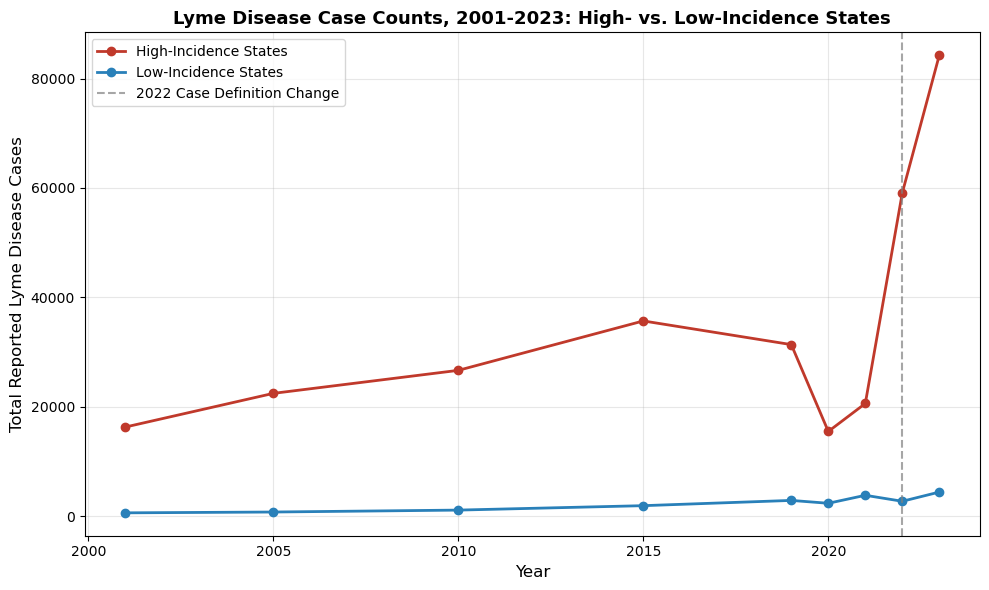

In [17]:
# Line Graph to Represent Lyme Disease Case Count throughout the years which come from SQL 
import matplotlib.pyplot as plt

years = [2001, 2005, 2010, 2015, 2019, 2020, 2021, 2022, 2023]
low_incidence = [586, 736, 1088, 1898, 2859, 2335, 3795, 2701, 4386]
high_incidence = [16278, 22438, 26649, 35685, 31356, 15470, 20588, 59106, 84286]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, high_incidence, marker='o', linewidth=2, label='High-Incidence States', color='#c0392b')
ax.plot(years, low_incidence, marker='o', linewidth=2, label='Low-Incidence States', color='#2980b9')

ax.axvline(x=2022, color='gray', linestyle='--', alpha=0.7, label='2022 Case Definition Change')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Reported Lyme Disease Cases', fontsize=12)
ax.set_title('Lyme Disease Case Counts, 2001-2023: High- vs. Low-Incidence States', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lyme_trend_chart.png', dpi=150)